# background_stats

> Calculate statistics to determine the surface brightness and spatial scale of the background variations.

In [ ]:
# | default_exp euclid.background_stats

In [ ]:
# | export

import os

import matplotlib.pyplot as plt
import numpy as np

from astropy.io import fits
from astropy import table
from matplotlib.ticker import FuncFormatter, NullLocator
from photutils.aperture import (
    CircularAperture,
    CircularAnnulus,
    RectangularAperture,
    RectangularAnnulus,
    ApertureStats,
)
from tqdm import tqdm

from nicl.mask import fast_mask, plot_mask

In [ ]:
# | hide

from FyeldGenerator import generate_field
from scipy.stats import norm

In [ ]:
# | export


def aperture_stats(
    data,
    mask,
    n_apertures,
    sqrt_n_pix,
    aperture_shape,
    annular_thickness=None,
    n_pix_tolerance=0.1,
):
    if aperture_shape == "square":
        outer_size = sqrt_n_pix
    if aperture_shape == "circle":
        outer_size = sqrt_n_pix * 2 / np.sqrt(np.pi)

    # adjust aperture sizes to account, on average, for masked pixels
    unmasked_frac = 1 - mask.sum() / mask.size
    outer_size /= np.sqrt(unmasked_frac)

    annulus = annular_thickness is not None and annular_thickness < 1
    if annulus:
        outer_size = outer_size / np.sqrt(1 - (1 - annular_thickness) ** 2)
        inner_size = (1 - annular_thickness) * outer_size
    else:
        inner_size = 0

    x = np.random.uniform(outer_size / 2, data.shape[1] - outer_size / 2, n_apertures)
    y = np.random.uniform(outer_size / 2, data.shape[0] - outer_size / 2, n_apertures)
    positions = np.transpose(np.vstack((x, y)))

    if aperture_shape == "square":
        if annulus:
            ap = RectangularAnnulus(
                positions,
                w_in=inner_size,
                w_out=outer_size,
                h_in=inner_size,
                h_out=outer_size,
            )
        else:
            ap = RectangularAperture(positions, w=outer_size, h=outer_size)
    elif aperture_shape == "circle":
        if annulus:
            ap = CircularAnnulus(positions, r_in=inner_size / 2, r_out=outer_size / 2)
        else:
            ap = CircularAperture(positions, r=outer_size / 2)

    stats = ApertureStats(data, ap, mask=mask)
    stats = stats.to_table(columns=("sum_aper_area", "mean", "median"))
    n_pix = sqrt_n_pix**2
    achieved_n_pix = stats["sum_aper_area"].value
    ok = abs(achieved_n_pix - n_pix) / n_pix < n_pix_tolerance
    n_ok = ok.sum()
    stats = stats[ok]
    std_mean = np.std(stats["mean"])
    err_std_mean = std_mean / np.sqrt(2 * n_ok - 2)
    std_median = np.std(stats["median"])
    err_std_median = std_median / np.sqrt(2 * n_ok - 2)
    results = dict(
        sqrt_n_pix=sqrt_n_pix,
        std_mean=std_mean,
        err_std_mean=err_std_mean,
        std_median=std_median,
        err_std_median=err_std_median,
        n_ok=n_ok,
        outer_size=outer_size,
    )
    return results

In [ ]:
# | export


def stats_versus_size(
    data,
    mask,
    n_apertures,
    max_sqrt_n_pix,
    aperture_shape,
    annular_thickness=None,
    n_pix_tolerance=0.1,
    n_steps=20,
):
    sqrt_n_pix_list = np.logspace(0, np.log10(max_sqrt_n_pix), n_steps)
    sqrt_n_pix_list = np.unique(sqrt_n_pix_list.astype(int))
    results = []
    for sqrt_n_pix in tqdm(sqrt_n_pix_list):
        results.append(
            aperture_stats(
                data,
                mask,
                n_apertures=n_apertures,
                sqrt_n_pix=sqrt_n_pix,
                aperture_shape=aperture_shape,
                annular_thickness=annular_thickness,
                n_pix_tolerance=n_pix_tolerance,
            )
        )
    results = table.Table(results)
    results["expected_std_mean"] = results["std_mean"][0] / results["sqrt_n_pix"]
    results["expected_std_median"] = (
        np.sqrt(np.pi / 2) * results["std_median"][0] / results["sqrt_n_pix"]
    )
    return results

In [ ]:
# | export


def background_stats_plot(results, true_bkg_std=None, errorbars=False):
    fig, ax = plt.subplots()
    ax.plot(
        results["sqrt_n_pix"],
        results["expected_std_mean"],
        "--",
        label="expected std(mean)",
    )
    if errorbars:
        ax.errorbar(
            results["sqrt_n_pix"],
            results["std_mean"],
            results["err_std_mean"],
            fmt="-o",
            label="measured std(mean)",
        )
    else:
        ax.plot(
            results["sqrt_n_pix"], results["std_mean"], "-o", label="measured std(mean)"
        )
    ax.plot(
        results["sqrt_n_pix"],
        results["expected_std_median"],
        "--",
        label="expected std(median)",
    )
    if errorbars:
        ax.errorbar(
            results["sqrt_n_pix"],
            results["std_median"],
            results["err_std_mean"],
            fmt="-o",
            label="measured std(median)",
        )
    else:
        ax.plot(
            results["sqrt_n_pix"],
            results["std_median"],
            "-o",
            label="measured std(median)",
        )
    if true_bkg_std is not None:
        ax.axhline(true_bkg_std, ls=":", label="true bkg std")
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
    ax.xaxis.set_ticks(results["sqrt_n_pix"])
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xlabel("sqrt(n_pix)")
    ax.set_ylabel("std(average)")
    ax.legend()

In [ ]:
# | export


def measure(
    filename,  # the filename to test
    path,  # the folder containing the images
    create_mask=True,  # generate and apply a mask
    estimate_background=True,  # allow masking to estimate the background from the median of the image
    plots=True,  # output plots
    outpath=None,  # the folder where all output plots should be placed
    separate_detectors=True,  # consider multiple science extensions individually
    n_apertures=100,  # number of apertures per size
    max_sqrt_n_pix=100,  # maximum aperture size as sqrt(number of pixels)
    aperture_shape="square",  # square or circle
    annular_thickness=None,  # None for solid apertures, or a number on range (0, 1) to specify relative thickness of annulus
    n_pix_tolerance=0.1,  # the largest allowed relative deviation from the requested n_pix
    n_steps=20,  # the number of different sqrt_n_pix to measure
):
    """Determine statistics of the background."""
    path = os.path.abspath(os.path.expanduser(path))
    if outpath is not None:
        outpath = os.path.abspath(os.path.expanduser(outpath))
    else:
        outpath = os.path.join(path, "background_stats")
    results = {}
    fn = os.path.join(path, filename)
    with fits.open(fn, memmap=True) as hdul:
        sci_ext = [hdu.name for hdu in hdul if "SCI" in hdu.name]
        for ext in sci_ext:
            data = hdul[ext].data
            rms = hdul[ext.replace("SCI", "RMS")].data
            data[rms > 1e6] = np.nan
            if create_mask:
                mask, _ = fast_mask(data, estimate_background=estimate_background)
            else:
                mask = np.zeros(data.shape, dtype=bool)
            ext_results = stats_versus_size(
                data,
                mask,
                n_apertures=n_apertures,
                max_sqrt_n_pix=max_sqrt_n_pix,
                aperture_shape=aperture_shape,
                annular_thickness=annular_thickness,
                n_pix_tolerance=n_pix_tolerance,
            )
            background_stats_plot(ext_results)
            results[ext] = ext_results
    if not separate_detectors:
        results = table.vstack(results.values())
    elif len(results) == 1:
        results = list(results.values())[0]
    return results

## Test

Test the performance on images containing random noise and a background varying on a particular spatial scale.

In [ ]:
def _distrib(shape):
    a = np.random.normal(loc=0, scale=1, size=shape)
    b = np.random.normal(loc=0, scale=1, size=shape)
    return a + 1j * b


def create_test_background(
    shape=(2040, 1020),  # shape of the simulated image,
    rms=1.0,  # rms of the Gaussian background noise, in absence of spatial variations
    background_scale=1000,  # scale, in pixels, of the spatial background variations
    background_rms=0.1,  # rms of the spatial background variations
):  # `random`, `background`, `random_with_background`
    """Create a background image for testing.

    A `random` flat background is created by sampling a Gaussian distribution with the
    specified `rms`. A spatially varying `background` is created as a Gaussian random field,
    with a Gaussian power spectrum, centred at zero wavelength with a standard deviation of
    1 / `background_scale`. This produces smooth spatial features on scales on the order of
    `background_scale`. This spatially varying background is scaled to have an rms of
    `background_rms`. The two are summed to produce `random_with_background`.
    """
    random = norm(0, rms).rvs(size=shape)
    background = generate_field(_distrib, norm(0, 1 / background_scale).pdf, shape)
    background *= background_rms / background.std()
    random_with_background = random + background
    return random, background, random_with_background


def create_test_mask(
    shape=(2040, 1020),  # shape of the simulated image,
    scale=100,  # scale, in pixels, of the spatial variations used to create the mask
    threshold=2,  # threshold of the spatial variations, as a multiple of the rms
):  # boolean `mask`, in which True means a pixel should be masked
    """Create an arbitrary mask for testing, by thresholding a Guassian random field."""
    mask = generate_field(_distrib, norm(0, 1 / scale).pdf, shape)
    mask = mask > threshold * mask.std()
    return mask

In [ ]:
random, background, random_with_background = create_test_background()

In [ ]:
mask = create_test_mask()
no_mask = mask * False

In [ ]:
def plot_test_images(random, background, random_with_background, mask):
    fig, ax = plt.subplots(1, 4, figsize=(12, 6))
    for a in ax:
        a.set_xticks([])
        a.set_yticks([])
    ax[0].imshow(random, cmap="seismic", interpolation="none")
    ax[1].imshow(background, cmap="seismic", interpolation="none")
    ax[2].imshow(random_with_background, cmap="seismic", interpolation="none")
    ax[3].imshow(mask, cmap="seismic", interpolation="none")
    plt.tight_layout()

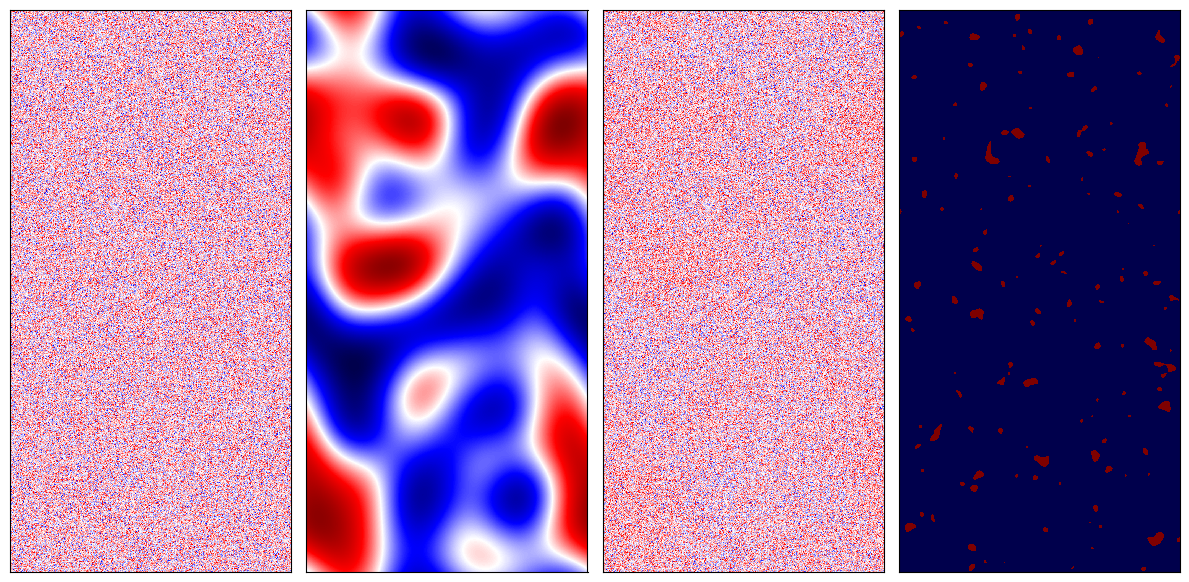

In [ ]:
plot_test_images(random, background, random_with_background, mask)

Calculate the standard deviation of the average over many apertures of a given size.

First with no mask and square apertures.

In [ ]:
results = aperture_stats(
    random,
    no_mask,
    n_apertures=100,
    sqrt_n_pix=100,
    aperture_shape="square",
    annular_thickness=None,
    n_pix_tolerance=0.1,
)
assert results["n_ok"] == 100
results

{'sqrt_n_pix': 100,
 'std_mean': 0.008730020740668162,
 'err_std_mean': 0.0006204155585699297,
 'std_median': 0.01275518902904953,
 'err_std_median': 0.0009064718127481943,
 'n_ok': 100,
 'outer_size': 100.0}

Now with a mask, note that `n_ok` decrease a bit, but the `outer_size` has increased to compensate for the masking.

In [ ]:
aperture_stats(random, mask, n_apertures=100, sqrt_n_pix=100, aperture_shape="square")

{'sqrt_n_pix': 100,
 'std_mean': 0.009103785856065168,
 'err_std_mean': 0.0006639618232467992,
 'std_median': 0.01137467719925264,
 'err_std_median': 0.0008295835964801407,
 'n_ok': 95,
 'outer_size': 101.20601591107784}

Try a square annulus. The `outer_size` has increased to achieve the same number of pixels.

In [ ]:
aperture_stats(
    random,
    mask,
    n_apertures=100,
    sqrt_n_pix=100,
    aperture_shape="square",
    annular_thickness=0.5,
)

{'sqrt_n_pix': 100,
 'std_mean': 0.009517459967067923,
 'err_std_mean': 0.000686863509248519,
 'std_median': 0.012510975555626786,
 'err_std_median': 0.0009029018881082442,
 'n_ok': 97,
 'outer_size': 116.86264105974068}

Try a circle. The `outer_size` has increased to achieve the same number of pixels as a square.

In [ ]:
aperture_stats(random, mask, n_apertures=100, sqrt_n_pix=100, aperture_shape="circle")

{'sqrt_n_pix': 100,
 'std_mean': 0.009640559674477316,
 'err_std_mean': 0.0006957474653997662,
 'std_median': 0.01269658096678332,
 'err_std_median': 0.0009162968048700287,
 'n_ok': 97,
 'outer_size': 114.19875993879722}

Try a circular annulus. Again, the `outer_size` has increased to achieve the same number of pixels.

In [ ]:
aperture_stats(
    random,
    mask,
    n_apertures=100,
    sqrt_n_pix=100,
    aperture_shape="circle",
    annular_thickness=0.5,
)

{'sqrt_n_pix': 100,
 'std_mean': 0.009523415669346547,
 'err_std_mean': 0.0006872933250377411,
 'std_median': 0.010884340748867894,
 'err_std_median': 0.0007855096326638115,
 'n_ok': 97,
 'outer_size': 131.86536958357206}

Now try with a spatially varying background. On small scales, the standard deviations match the original pixel rms, but on larger scales they match the strength of the background variations.

In [ ]:
aperture_stats(
    random_with_background, mask, n_apertures=100, sqrt_n_pix=1, aperture_shape="square"
)

{'sqrt_n_pix': 1,
 'std_mean': 0.994003834495547,
 'err_std_mean': 0.07064077652489142,
 'std_median': 0.994003834495547,
 'err_std_median': 0.07064077652489142,
 'n_ok': 100,
 'outer_size': 1.0120601591107785}

In [ ]:
aperture_stats(
    random_with_background,
    mask,
    n_apertures=1000,
    sqrt_n_pix=100,
    aperture_shape="square",
)

{'sqrt_n_pix': 100,
 'std_mean': 0.09225821921633273,
 'err_std_mean': 0.002098947164475387,
 'std_median': 0.09311540604606872,
 'err_std_median': 0.00211844884010909,
 'n_ok': 967,
 'outer_size': 101.20601591107784}

Now let's measure the statistics in apertures of a series of sizes. First with no spatially varying background.

In [ ]:
results_no_bkg = stats_versus_size(
    random, mask, n_apertures=100, max_sqrt_n_pix=60, aperture_shape="square"
)

100%|██████████| 16/16 [00:01<00:00,  8.87it/s]


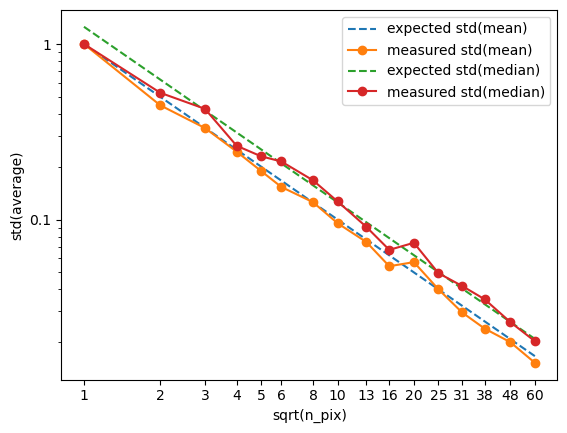

In [ ]:
background_stats_plot(results_no_bkg)

And now with a spatially varying background.

In [ ]:
results_with_bkg = stats_versus_size(
    random_with_background,
    mask,
    n_apertures=100,
    max_sqrt_n_pix=60,
    aperture_shape="square",
)

100%|██████████| 16/16 [00:01<00:00,  8.67it/s]


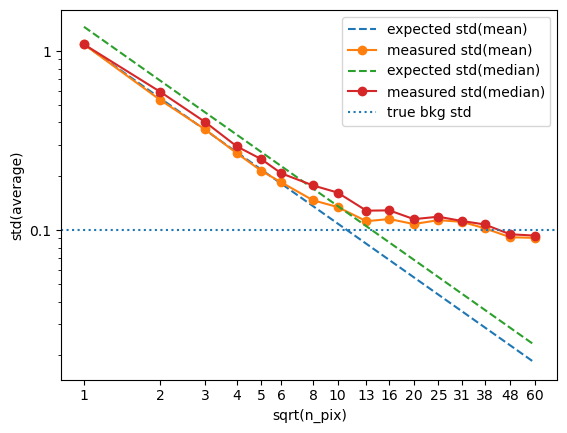

In [ ]:
background_stats_plot(results_with_bkg, true_bkg_std=0.1)

Create a background containing spatial variations with a different rms, to compare.

In [ ]:
random, background, random_with_background = create_test_background(background_rms=0.2)

In [ ]:
results_with_bkg = stats_versus_size(
    random_with_background,
    mask,
    n_apertures=100,
    max_sqrt_n_pix=60,
    aperture_shape="square",
)

100%|██████████| 16/16 [00:02<00:00,  7.21it/s]


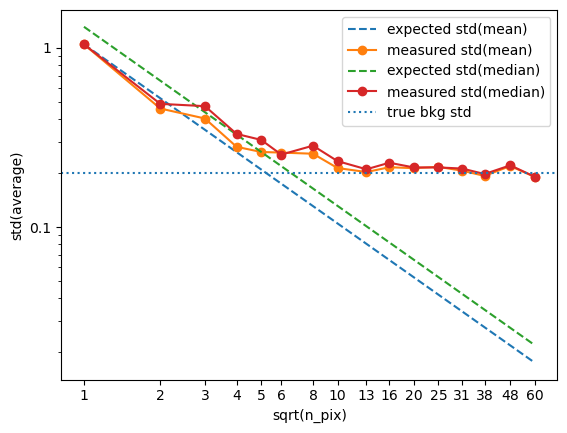

In [ ]:
background_stats_plot(results_with_bkg, true_bkg_std=0.2)

Create a background containing spatial variations on a different scale, to compare.

In [ ]:
random, background, random_with_background = create_test_background(
    background_scale=100
)

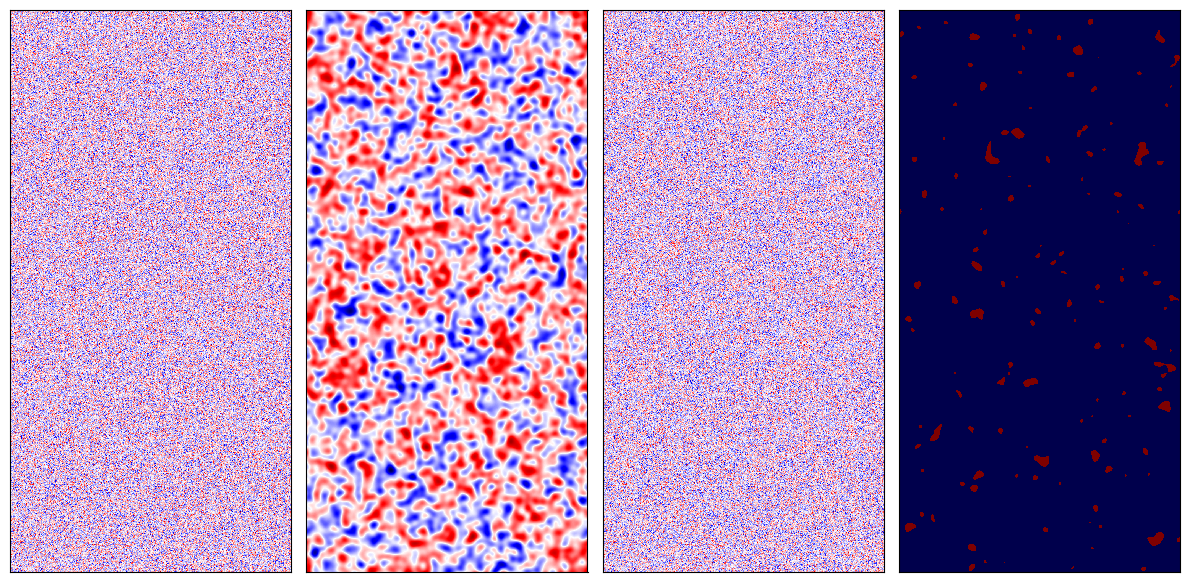

In [ ]:
plot_test_images(random, background, random_with_background, mask)

In [ ]:
results_with_bkg = stats_versus_size(
    random_with_background,
    mask,
    n_apertures=100,
    max_sqrt_n_pix=60,
    aperture_shape="square",
)

100%|██████████| 16/16 [00:01<00:00,  8.16it/s]


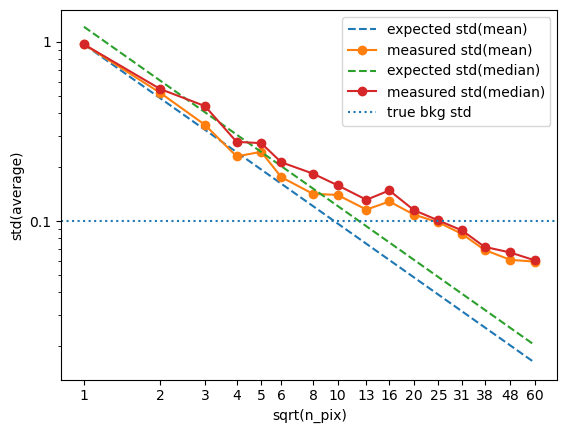

In [ ]:
background_stats_plot(results_with_bkg, true_bkg_std=0.1)

## Example

The following is an example of using `background_stats.run` on an observation.

In [ ]:
path = "/Users/spb/data/euclid/q1/clusters/MCXC_J1743.3+6440/stacked/"
filename = "EUC_NIR_W-STK-IMAGE-2070.fits"

0.2749579 0.02676496889160071
0.27311566 0.025295950552722084
0.27302474 0.0252450494450616


100%|██████████| 17/17 [00:05<00:00,  3.30it/s]


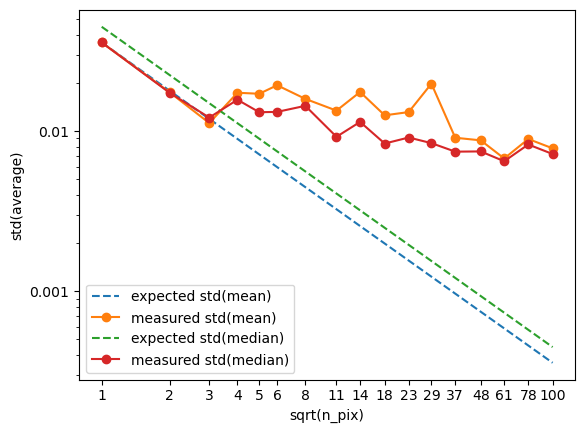

In [ ]:
results = measure(filename, path)

In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()